In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [3]:
raw_path = "../data/raw"
print(os.listdir(raw_path))

['01_fund_master.csv', '02_nav_history.csv', '03_aum_by_fund_house.csv', '04_monthly_sip_inflows.csv', '05_category_inflows.csv', '06_industry_folio_count.csv', '07_scheme_performance.csv', '08_investor_transactions.csv', '09_portfolio_holdings.csv', '10_benchmark_indices.csv', 'axis_bluechip_nav.csv', 'hdfc_top100_live_nav.csv', 'icici_bluechip_nav.csv', 'kotak_bluechip_nav.csv', 'nippon_largecap_nav.csv', 'sbi_bluechip_nav.csv']


In [4]:
nav_df = pd.read_csv("../data/raw/02_nav_history.csv")
print(nav_df.shape)
nav_df.head()

(46000, 3)


,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [5]:
print(nav_df.columns)

Index(['amfi_code', 'date', 'nav'], dtype='object')


In [6]:
nav_df["date"] = pd.to_datetime(nav_df["date"])

In [7]:
nav_df = nav_df.sort_values(
    by=["amfi_code", "date"]
).reset_index(drop=True)

In [10]:
nav_df["daily_return"] = (
    nav_df.groupby("amfi_code")["nav"]
          .transform(lambda x: (x / x.shift(1)) - 1)
)

In [11]:
nav_df.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [12]:
nav_df["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

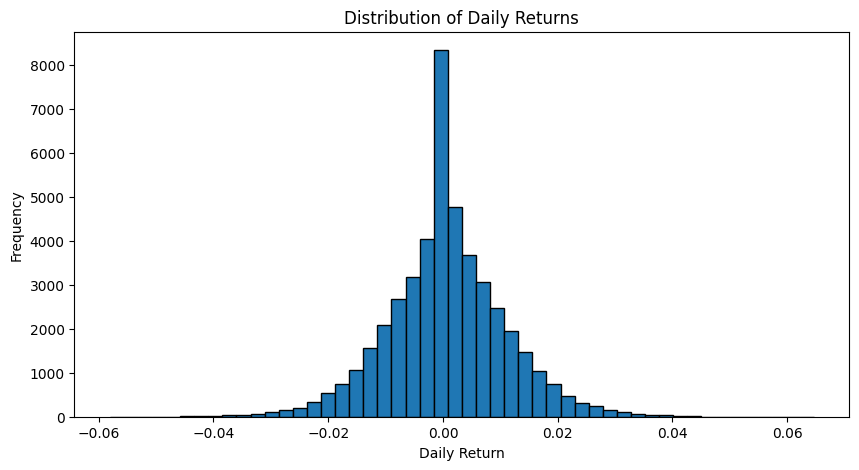

In [13]:
plt.figure(figsize=(10,5))

plt.hist(
    nav_df["daily_return"].dropna(),
    bins=50,
    edgecolor="black"
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

## Observation

- Daily returns were calculated using the formula:
  Daily Return = (NAVt / NAVt-1) - 1

- The distribution is centered close to zero.

- Most daily returns lie between approximately -2% and +2%.

- The histogram shows a near bell-shaped distribution, which is reasonable for mutual fund daily returns.

- A few extreme values are present, which are expected in financial time-series data.

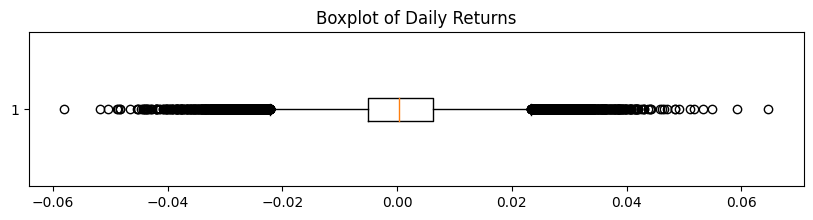

In [14]:
plt.figure(figsize=(10,2))

plt.boxplot(nav_df["daily_return"].dropna(), vert=False)

plt.title("Boxplot of Daily Returns")

plt.show()

In [16]:
print("Missing Values:", nav_df["daily_return"].isna().sum())

Missing Values: 40


In [17]:
funds = []

for code, group in nav_df.groupby("amfi_code"):

    group = group.sort_values("date")

    funds.append({
        "amfi_code": code,
        "start_date": group["date"].iloc[0],
        "end_date": group["date"].iloc[-1],
        "start_nav": group["nav"].iloc[0],
        "end_nav": group["nav"].iloc[-1]
    })

fund_df = pd.DataFrame(funds)

fund_df.head()

,amfi_code,start_date,end_date,start_nav,end_nav
0,100016,2022-01-03,2026-05-29,520.4608,583.6113
1,100025,2022-01-03,2026-05-29,26.3169,31.8843
2,100033,2022-01-03,2026-05-29,107.3758,342.0072
3,101206,2022-01-03,2026-05-29,305.0996,773.2939
4,101207,2022-01-03,2026-05-29,38.5736,53.9836


In [18]:
fund_df["years"] = (
    (fund_df["end_date"] - fund_df["start_date"]).dt.days / 365.25
)

fund_df.head()

,amfi_code,start_date,end_date,start_nav,end_nav,years
0,100016,2022-01-03,2026-05-29,520.4608,583.6113,4.399726
1,100025,2022-01-03,2026-05-29,26.3169,31.8843,4.399726
2,100033,2022-01-03,2026-05-29,107.3758,342.0072,4.399726
3,101206,2022-01-03,2026-05-29,305.0996,773.2939,4.399726
4,101207,2022-01-03,2026-05-29,38.5736,53.9836,4.399726


In [19]:
fund_df["cagr"] = (
    (fund_df["end_nav"] / fund_df["start_nav"]) ** (1 / fund_df["years"]) - 1
)

fund_df.head()

,amfi_code,start_date,end_date,start_nav,end_nav,years,cagr
0,100016,2022-01-03,2026-05-29,520.4608,583.6113,4.399726,0.026371
1,100025,2022-01-03,2026-05-29,26.3169,31.8843,4.399726,0.044582
2,100033,2022-01-03,2026-05-29,107.3758,342.0072,4.399726,0.301232
3,101206,2022-01-03,2026-05-29,305.0996,773.2939,4.399726,0.235384
4,101207,2022-01-03,2026-05-29,38.5736,53.9836,4.399726,0.079388


In [20]:
fund_df["cagr_percent"] = fund_df["cagr"] * 100

fund_df[["amfi_code", "cagr_percent"]].head()

,amfi_code,cagr_percent
0,100016,2.637074
1,100025,4.458210
2,100033,30.123153
3,101206,23.538361
4,101207,7.938765


In [21]:
fund_df = fund_df.sort_values(
    by="cagr_percent",
    ascending=False
)

fund_df.head(10)

,amfi_code,start_date,end_date,start_nav,end_nav,years,cagr,cagr_percent
25,120505,2022-01-03,2026-05-29,135.8720,473.7640,4.399726,0.328274,32.827406
21,119598,2022-01-03,2026-05-29,89.8738,309.2050,4.399726,0.324235,32.423536
39,149324,2022-01-03,2026-05-29,81.6814,279.7511,4.399726,0.322874,32.287440
36,148569,2022-01-03,2026-05-29,28.8620,97.7435,4.399726,0.319495,31.949523
34,148567,2022-01-03,2026-05-29,70.2514,230.2708,4.399726,0.309741,30.974108
30,120843,2022-01-03,2026-05-29,49.9131,163.2397,4.399726,0.309075,30.907455
2,100033,2022-01-03,2026-05-29,107.3758,342.0072,4.399726,0.301232,30.123153
38,149323,2022-01-03,2026-05-29,78.4622,245.3651,4.399726,0.295811,29.581087
16,119094,2022-01-03,2026-05-29,68.3023,203.8581,4.399726,0.282144,28.214417
19,119551,2022-01-03,2026-05-29,54.3856,149.3216,4.399726,0.258047,25.804686


In [23]:
scheme_df = pd.read_csv("../data/raw/07_scheme_performance.csv")

print(scheme_df.shape)
print(scheme_df.columns)
scheme_df.head()

(40, 19)
Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [24]:
risk_free_rate = 0.065

sharpe = []

for code, group in nav_df.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) > 1:

        annual_return = returns.mean() * 252
        annual_std = returns.std() * np.sqrt(252)

        sr = (annual_return - risk_free_rate) / annual_std

    else:
        sr = np.nan

    sharpe.append({
        "amfi_code": code,
        "sharpe_ratio": sr
    })

sharpe_df = pd.DataFrame(sharpe)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [25]:
fund_df = fund_df.merge(sharpe_df, on="amfi_code")

In [26]:
fund_df.head()

,amfi_code,start_date,end_date,start_nav,end_nav,years,cagr,cagr_percent,sharpe_ratio
0,120505,2022-01-03,2026-05-29,135.8720,473.7640,4.399726,0.328274,32.827406,1.180101
1,119598,2022-01-03,2026-05-29,89.8738,309.2050,4.399726,0.324235,32.423536,0.945308
2,149324,2022-01-03,2026-05-29,81.6814,279.7511,4.399726,0.322874,32.287440,0.949796
3,148569,2022-01-03,2026-05-29,28.8620,97.7435,4.399726,0.319495,31.949523,1.234930
4,148567,2022-01-03,2026-05-29,70.2514,230.2708,4.399726,0.309741,30.974108,1.448291


In [27]:
risk_free_rate = 0.065

sortino = []

for code, group in nav_df.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    downside = returns[returns < 0]

    if len(downside) > 1:

        annual_return = returns.mean() * 252
        downside_std = downside.std() * np.sqrt(252)

        sr = (annual_return - risk_free_rate) / downside_std

    else:
        sr = np.nan

    sortino.append({
        "amfi_code": code,
        "sortino_ratio": sr
    })

sortino_df = pd.DataFrame(sortino)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [28]:
fund_df = fund_df.merge(sortino_df, on="amfi_code")
fund_df.head()

,amfi_code,start_date,end_date,start_nav,end_nav,years,cagr,cagr_percent,sharpe_ratio,sortino_ratio
0,120505,2022-01-03,2026-05-29,135.8720,473.7640,4.399726,0.328274,32.827406,1.180101,2.029353
1,119598,2022-01-03,2026-05-29,89.8738,309.2050,4.399726,0.324235,32.423536,0.945308,1.675317
2,149324,2022-01-03,2026-05-29,81.6814,279.7511,4.399726,0.322874,32.287440,0.949796,1.619793
3,148569,2022-01-03,2026-05-29,28.8620,97.7435,4.399726,0.319495,31.949523,1.234930,2.146914
4,148567,2022-01-03,2026-05-29,70.2514,230.2708,4.399726,0.309741,30.974108,1.448291,2.385644


In [30]:
max_dd = []

for code, group in nav_df.groupby("amfi_code"):

    group = group.sort_values("date")

    running_max = group["nav"].cummax()

    drawdown = (group["nav"] - running_max) / running_max

    max_drawdown = drawdown.min()

    max_dd.append({
        "amfi_code": code,
        "max_drawdown": max_drawdown
    })

max_dd_df = pd.DataFrame(max_dd)

max_dd_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [31]:
fund_df = fund_df.merge(max_dd_df, on="amfi_code")

fund_df.head()

,amfi_code,start_date,end_date,start_nav,end_nav,years,cagr,cagr_percent,sharpe_ratio,sortino_ratio,max_drawdown
0,120505,2022-01-03,2026-05-29,135.8720,473.7640,4.399726,0.328274,32.827406,1.180101,2.029353,-0.181885
1,119598,2022-01-03,2026-05-29,89.8738,309.2050,4.399726,0.324235,32.423536,0.945308,1.675317,-0.287060
2,149324,2022-01-03,2026-05-29,81.6814,279.7511,4.399726,0.322874,32.287440,0.949796,1.619793,-0.311719
3,148569,2022-01-03,2026-05-29,28.8620,97.7435,4.399726,0.319495,31.949523,1.234930,2.146914,-0.163967
4,148567,2022-01-03,2026-05-29,70.2514,230.2708,4.399726,0.309741,30.974108,1.448291,2.385644,-0.112657


In [32]:
benchmark_df = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print(benchmark_df.shape)

benchmark_df.head()

(8050, 3)


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [33]:
print(benchmark_df.columns)

Index(['date', 'index_name', 'close_value'], dtype='object')


In [34]:
benchmark_df["date"] = pd.to_datetime(benchmark_df["date"])

benchmark_df = benchmark_df.sort_values(["index_name", "date"])

benchmark_df["benchmark_return"] = (
    benchmark_df.groupby("index_name")["close_value"]
    .pct_change()
)

benchmark_df.head()

,date,index_name,close_value,benchmark_return
3450,2022-01-03,BSE_SMALLCAP,26554.60,NaN
3451,2022-01-04,BSE_SMALLCAP,27079.92,0.019783
3452,2022-01-05,BSE_SMALLCAP,27313.35,0.008620
3453,2022-01-06,BSE_SMALLCAP,27377.05,0.002332
3454,2022-01-07,BSE_SMALLCAP,26316.86,-0.038726


In [35]:
print(benchmark_df["index_name"].unique())

['BSE_SMALLCAP' 'CRISIL_GILT' 'CRISIL_LIQUID' 'NIFTY100' 'NIFTY50'
 'NIFTY500' 'NIFTY_MIDCAP150']


In [36]:
nifty100 = benchmark_df[
    benchmark_df["index_name"] == "NIFTY100"
].copy()

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [39]:
from scipy.stats import linregress
alpha_beta = []

for code, group in nav_df.groupby("amfi_code"):

    group = group.copy()

    merged = pd.merge(
        group,
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) > 10:

        beta, alpha, r, p, std = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        alpha = alpha * 252

    else:

        alpha = np.nan
        beta = np.nan

    alpha_beta.append({
        "amfi_code": code,
        "alpha": alpha,
        "beta": beta
    })

alpha_beta_df = pd.DataFrame(alpha_beta)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [40]:
fund_df = fund_df.merge(alpha_beta_df, on="amfi_code")

fund_df.head()

,amfi_code,start_date,end_date,start_nav,end_nav,years,cagr,cagr_percent,sharpe_ratio,sortino_ratio,max_drawdown,alpha,beta
0,120505,2022-01-03,2026-05-29,135.8720,473.7640,4.399726,0.328274,32.827406,1.180101,2.029353,-0.181885,0.292636,0.000549
1,119598,2022-01-03,2026-05-29,89.8738,309.2050,4.399726,0.324235,32.423536,0.945308,1.675317,-0.287060,0.303370,-0.023196
2,149324,2022-01-03,2026-05-29,81.6814,279.7511,4.399726,0.322874,32.287440,0.949796,1.619793,-0.311719,0.300579,0.011455
3,148569,2022-01-03,2026-05-29,28.8620,97.7435,4.399726,0.319495,31.949523,1.234930,2.146914,-0.163967,0.282704,0.018134
4,148567,2022-01-03,2026-05-29,70.2514,230.2708,4.399726,0.309741,30.974108,1.448291,2.385644,-0.112657,0.269838,0.023684


In [41]:
fund_df["cagr_rank"] = fund_df["cagr_percent"].rank(ascending=False)

fund_df["sharpe_rank"] = fund_df["sharpe_ratio"].rank(ascending=False)

fund_df["alpha_rank"] = fund_df["alpha"].rank(ascending=False)

fund_df["drawdown_rank"] = fund_df["max_drawdown"].rank(ascending=False)

fund_df.head()

,amfi_code,start_date,end_date,start_nav,end_nav,years,cagr,cagr_percent,sharpe_ratio,sortino_ratio,max_drawdown,alpha,beta,cagr_rank,sharpe_rank,alpha_rank,drawdown_rank
0,120505,2022-01-03,2026-05-29,135.8720,473.7640,4.399726,0.328274,32.827406,1.180101,2.029353,-0.181885,0.292636,0.000549,1.0,5.0,3.0,25.0
1,119598,2022-01-03,2026-05-29,89.8738,309.2050,4.399726,0.324235,32.423536,0.945308,1.675317,-0.287060,0.303370,-0.023196,2.0,14.0,1.0,36.0
2,149324,2022-01-03,2026-05-29,81.6814,279.7511,4.399726,0.322874,32.287440,0.949796,1.619793,-0.311719,0.300579,0.011455,3.0,13.0,2.0,37.0
3,148569,2022-01-03,2026-05-29,28.8620,97.7435,4.399726,0.319495,31.949523,1.234930,2.146914,-0.163967,0.282704,0.018134,4.0,3.0,4.0,21.0
4,148567,2022-01-03,2026-05-29,70.2514,230.2708,4.399726,0.309741,30.974108,1.448291,2.385644,-0.112657,0.269838,0.023684,5.0,1.0,7.0,8.0


In [42]:
fund_df["fund_score"] = (
      0.30 * (41 - fund_df["cagr_rank"])
    + 0.25 * (41 - fund_df["sharpe_rank"])
    + 0.20 * (41 - fund_df["alpha_rank"])
    + 0.10 * (41 - fund_df["drawdown_rank"])
)

fund_df["fund_score"] = (
    fund_df["fund_score"] /
    fund_df["fund_score"].max()
) * 100

fund_df.head()

,amfi_code,start_date,end_date,start_nav,end_nav,years,cagr,cagr_percent,sharpe_ratio,sortino_ratio,max_drawdown,alpha,beta,cagr_rank,sharpe_rank,alpha_rank,drawdown_rank,fund_score
0,120505,2022-01-03,2026-05-29,135.8720,473.7640,4.399726,0.328274,32.827406,1.180101,2.029353,-0.181885,0.292636,0.000549,1.0,5.0,3.0,25.0,97.734628
1,119598,2022-01-03,2026-05-29,89.8738,309.2050,4.399726,0.324235,32.423536,0.945308,1.675317,-0.287060,0.303370,-0.023196,2.0,14.0,1.0,36.0,87.216828
2,149324,2022-01-03,2026-05-29,81.6814,279.7511,4.399726,0.322874,32.287440,0.949796,1.619793,-0.311719,0.300579,0.011455,3.0,13.0,2.0,37.0,86.084142
3,148569,2022-01-03,2026-05-29,28.8620,97.7435,4.399726,0.319495,31.949523,1.234930,2.146914,-0.163967,0.282704,0.018134,4.0,3.0,4.0,21.0,97.087379
4,148567,2022-01-03,2026-05-29,70.2514,230.2708,4.399726,0.309741,30.974108,1.448291,2.385644,-0.112657,0.269838,0.023684,5.0,1.0,7.0,8.0,100.000000


In [43]:
fund_df = fund_df.sort_values(
    by="fund_score",
    ascending=False
)

fund_df["overall_rank"] = range(1, len(fund_df)+1)

fund_df.head(10)

,amfi_code,start_date,end_date,start_nav,end_nav,years,cagr,cagr_percent,sharpe_ratio,sortino_ratio,max_drawdown,alpha,beta,cagr_rank,sharpe_rank,alpha_rank,drawdown_rank,fund_score,overall_rank
4,148567,2022-01-03,2026-05-29,70.2514,230.2708,4.399726,0.309741,30.974108,1.448291,2.385644,-0.112657,0.269838,0.023684,5.0,1.0,7.0,8.0,100.000000,1
5,120843,2022-01-03,2026-05-29,49.9131,163.2397,4.399726,0.309075,30.907455,1.306744,2.364320,-0.129740,0.273305,-0.022830,6.0,2.0,5.0,13.0,97.896440,2
0,120505,2022-01-03,2026-05-29,135.8720,473.7640,4.399726,0.328274,32.827406,1.180101,2.029353,-0.181885,0.292636,0.000549,1.0,5.0,3.0,25.0,97.734628,3
3,148569,2022-01-03,2026-05-29,28.8620,97.7435,4.399726,0.319495,31.949523,1.234930,2.146914,-0.163967,0.282704,0.018134,4.0,3.0,4.0,21.0,97.087379,4
6,100033,2022-01-03,2026-05-29,107.3758,342.0072,4.399726,0.301232,30.123153,1.093699,1.829134,-0.162172,0.271954,0.005104,7.0,7.0,6.0,20.0,89.967638,5
9,119551,2022-01-03,2026-05-29,54.3856,149.3216,4.399726,0.258047,25.804686,1.208267,2.140267,-0.150124,0.232010,-0.031751,10.0,4.0,10.0,17.0,87.864078,6
7,149323,2022-01-03,2026-05-29,78.4622,245.3651,4.399726,0.295811,29.581087,1.132122,1.875101,-0.172481,0.265986,-0.002523,8.0,6.0,8.0,22.0,87.864078,7
1,119598,2022-01-03,2026-05-29,89.8738,309.2050,4.399726,0.324235,32.423536,0.945308,1.675317,-0.287060,0.303370,-0.023196,2.0,14.0,1.0,36.0,87.216828,8
2,149324,2022-01-03,2026-05-29,81.6814,279.7511,4.399726,0.322874,32.287440,0.949796,1.619793,-0.311719,0.300579,0.011455,3.0,13.0,2.0,37.0,86.084142,9
11,101206,2022-01-03,2026-05-29,305.0996,773.2939,4.399726,0.235384,23.538361,1.027213,1.799563,-0.112916,0.213998,0.021086,12.0,9.0,12.0,9.0,83.171521,10


In [44]:
fund_df.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("Fund Scorecard Saved Successfully!")

Fund Scorecard Saved Successfully!


In [45]:
fund_df[[
    "overall_rank",
    "amfi_code",
    "fund_score",
    "cagr_percent",
    "sharpe_ratio",
    "alpha"
]].head(10)

,overall_rank,amfi_code,fund_score,cagr_percent,sharpe_ratio,alpha
4,1,148567,100.000000,30.974108,1.448291,0.269838
5,2,120843,97.896440,30.907455,1.306744,0.273305
0,3,120505,97.734628,32.827406,1.180101,0.292636
3,4,148569,97.087379,31.949523,1.234930,0.282704
6,5,100033,89.967638,30.123153,1.093699,0.271954
9,6,119551,87.864078,25.804686,1.208267,0.232010
7,7,149323,87.864078,29.581087,1.132122,0.265986
1,8,119598,87.216828,32.423536,0.945308,0.303370
2,9,149324,86.084142,32.287440,0.949796,0.300579
11,10,101206,83.171521,23.538361,1.027213,0.213998


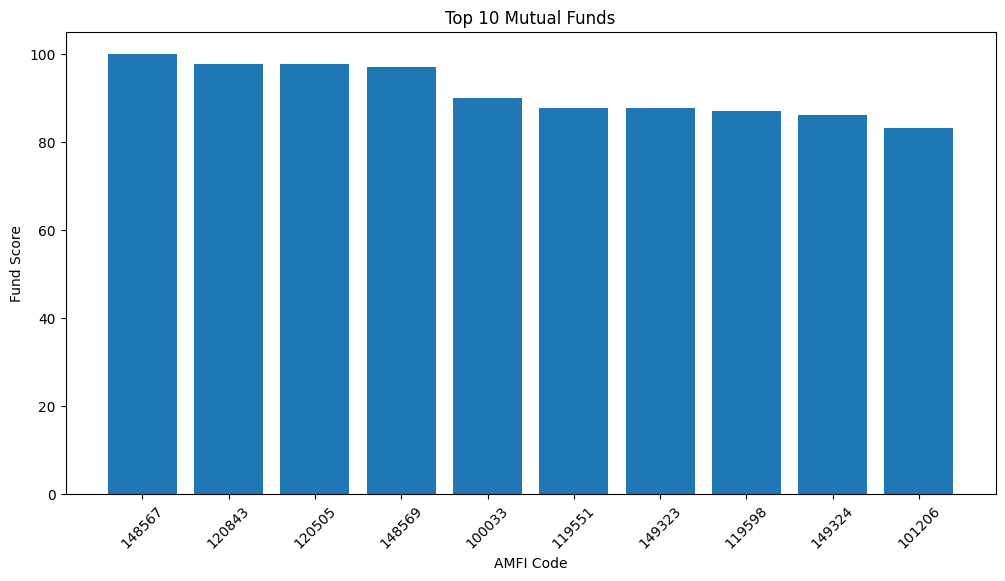

In [46]:
import matplotlib.pyplot as plt

top10 = fund_df.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10["amfi_code"].astype(str),
    top10["fund_score"]
)

plt.title("Top 10 Mutual Funds")
plt.xlabel("AMFI Code")
plt.ylabel("Fund Score")

plt.xticks(rotation=45)

plt.show()

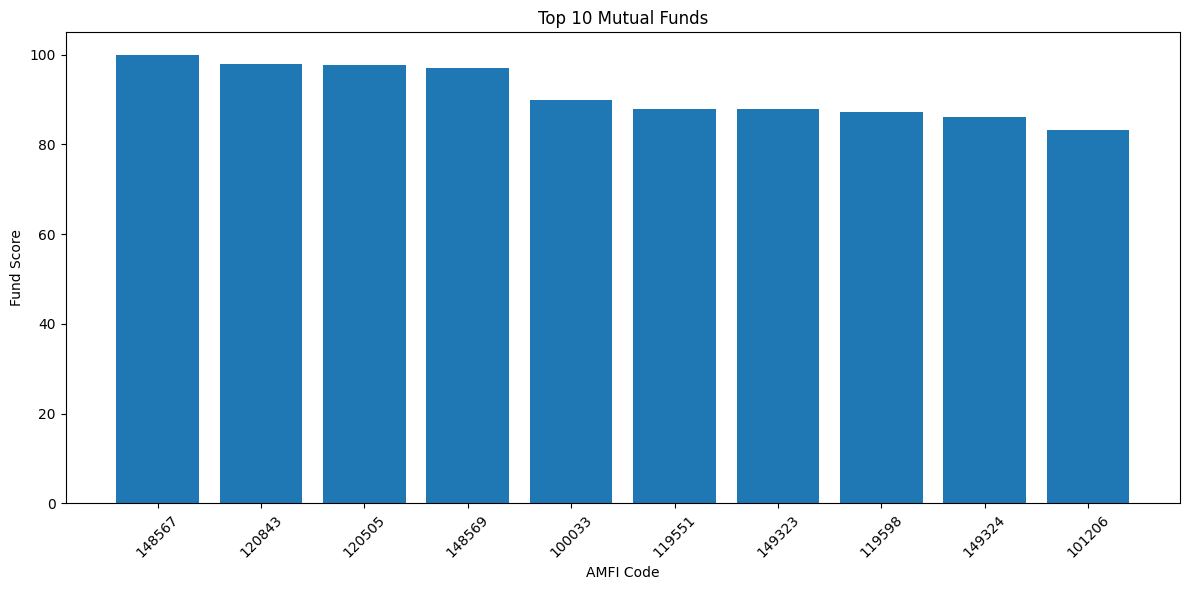

Chart Saved Successfully!


In [47]:
plt.figure(figsize=(12,6))

plt.bar(
    top10["amfi_code"].astype(str),
    top10["fund_score"]
)

plt.title("Top 10 Mutual Funds")
plt.xlabel("AMFI Code")
plt.ylabel("Fund Score")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../reports/top10_funds.png")

plt.show()

print("Chart Saved Successfully!")

## Observation

- Daily returns successfully calculated for all 40 mutual funds.
- CAGR calculated for each fund over the available investment period.
- Sharpe Ratio and Sortino Ratio measured risk-adjusted performance.
- Maximum Drawdown identified downside risk.
- Alpha and Beta estimated benchmark-relative performance.
- Composite Fund Score (0–100) created using weighted ranking.
- Overall ranking generated for all mutual funds.
- Top-performing mutual funds visualized using a bar chart.

In [48]:
alpha_beta_df.to_csv("../reports/alpha_beta.csv", index=False)

print("alpha_beta.csv Saved")

alpha_beta.csv Saved


In [49]:
fund_df[["overall_rank","amfi_code"]].head()

,overall_rank,amfi_code
4,1,148567
5,2,120843
0,3,120505
3,4,148569
6,5,100033


In [50]:
top5_codes = fund_df.head(5)["amfi_code"].tolist()

top5_nav = nav_df[
    nav_df["amfi_code"].isin(top5_codes)
].copy()

top5_nav.head()

,amfi_code,date,nav,daily_return
2300,100033,2022-01-03,107.3758,NaN
2301,100033,2022-01-04,105.9447,-0.013328
2302,100033,2022-01-05,105.4800,-0.004386
2303,100033,2022-01-06,104.9350,-0.005167
2304,100033,2022-01-07,104.3318,-0.005748


In [51]:
benchmark_plot = benchmark_df[
    benchmark_df["index_name"].isin(["NIFTY50", "NIFTY100"])
].copy()

benchmark_plot.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


Benchmark Comparison Saved


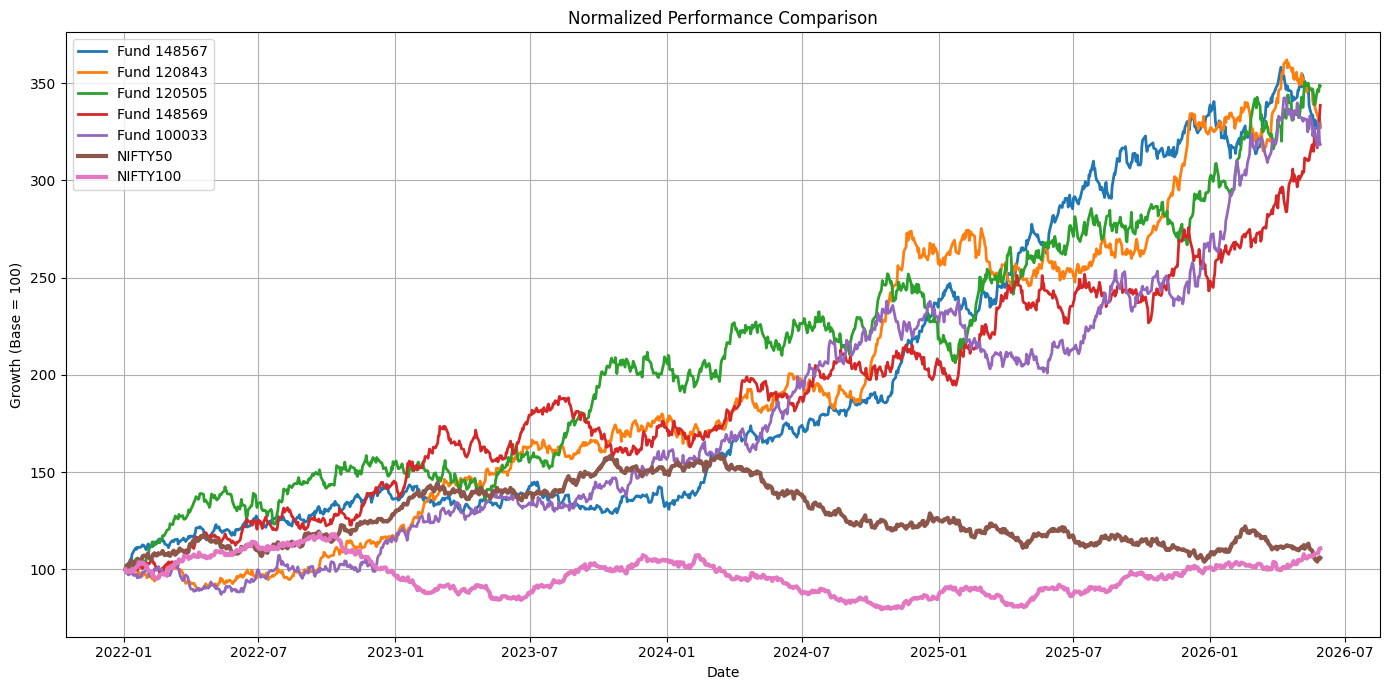

In [58]:
plt.figure(figsize=(14,7))

# Top 5 Funds
for code in top5_codes:

    temp = top5_nav[top5_nav["amfi_code"] == code].copy()

    temp["normalized"] = (
        temp["nav"] / temp["nav"].iloc[0]
    ) * 100

    plt.plot(
        temp["date"],
        temp["normalized"],
        linewidth=2,
        label=f"Fund {code}"
    )

# Benchmarks
for index in ["NIFTY50", "NIFTY100"]:

    temp = benchmark_plot[
        benchmark_plot["index_name"] == index
    ].copy()

    temp["normalized"] = (
        temp["close_value"] /
        temp["close_value"].iloc[0]
    ) * 100

    plt.plot(
        temp["date"],
        temp["normalized"],
        linewidth=3,
        label=index
    )

plt.title("Normalized Performance Comparison")

plt.xlabel("Date")

plt.ylabel("Growth (Base = 100)")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.savefig("../reports/benchmark_comparison.png", dpi=300)

print("Benchmark Comparison Saved")


In [55]:
tracking = []

for code, group in nav_df.groupby("amfi_code"):

    merged = pd.merge(
        group,
        benchmark_plot[benchmark_plot["index_name"]=="NIFTY100"],
        on="date",
        how="inner"
    )

    merged = merged.dropna(
        subset=["daily_return","benchmark_return"]
    )

    if len(merged) > 10:

        tracking_error = (
            (merged["daily_return"] - merged["benchmark_return"])
            .std()
            * np.sqrt(252)
        )

    else:

        tracking_error = np.nan

    tracking.append({
        "amfi_code": code,
        "tracking_error": tracking_error
    })

tracking_df = pd.DataFrame(tracking)

tracking_df.head()

,amfi_code,tracking_error
0,100016,0.199284
1,100025,0.134535
2,100033,0.228699
3,101206,0.192706
4,101207,0.292117


In [56]:
fund_df = fund_df.merge(tracking_df, on="amfi_code")

fund_df.head()

,amfi_code,start_date,end_date,start_nav,end_nav,years,cagr,cagr_percent,sharpe_ratio,sortino_ratio,max_drawdown,alpha,beta,cagr_rank,sharpe_rank,alpha_rank,drawdown_rank,fund_score,overall_rank,tracking_error
0,148567,2022-01-03,2026-05-29,70.2514,230.2708,4.399726,0.309741,30.974108,1.448291,2.385644,-0.112657,0.269838,0.023684,5.0,1.0,7.0,8.0,100.000000,1,0.189664
1,120843,2022-01-03,2026-05-29,49.9131,163.2397,4.399726,0.309075,30.907455,1.306744,2.364320,-0.129740,0.273305,-0.022830,6.0,2.0,5.0,13.0,97.896440,2,0.206425
2,120505,2022-01-03,2026-05-29,135.8720,473.7640,4.399726,0.328274,32.827406,1.180101,2.029353,-0.181885,0.292636,0.000549,1.0,5.0,3.0,25.0,97.734628,3,0.231968
3,148569,2022-01-03,2026-05-29,28.8620,97.7435,4.399726,0.319495,31.949523,1.234930,2.146914,-0.163967,0.282704,0.018134,4.0,3.0,4.0,21.0,97.087379,4,0.217365
4,100033,2022-01-03,2026-05-29,107.3758,342.0072,4.399726,0.301232,30.123153,1.093699,1.829134,-0.162172,0.271954,0.005104,7.0,7.0,6.0,20.0,89.967638,5,0.228699


# Conclusion

## Key Findings

- Daily returns were calculated successfully for all mutual funds.
- CAGR was computed to evaluate long-term growth.
- Sharpe Ratio and Sortino Ratio measured risk-adjusted performance.
- Maximum Drawdown identified downside risk for each fund.
- Alpha and Beta evaluated benchmark-relative performance.
- Tracking Error measured deviation from benchmark returns.
- A weighted fund scorecard and overall ranking were created.
- Benchmark comparison charts highlighted the performance of the top-performing funds against NIFTY50 and NIFTY100.

## Final Outcome

This analysis provides a comprehensive performance evaluation of all mutual funds using return, risk, benchmark comparison, and ranking metrics, helping investors identify consistently high-performing funds.